In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from zipfile import ZipFile
import warnings
import glob
import os
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize']= (12,6)
plt.rcParams['font.size'] = 12
print("Import succées")

Import succées


In [78]:

# Extract the data from files
# -- Data_description.txt
# -- Sample_submissions.csv
# -- test.csv
# -- train.csv
with ZipFile("../data/house-prices-advanced-regression-techniques.zip",'r') as zip_ref:
    zip_ref.extractall("../data/")
print(os.listdir("../data/"))
with open("../data/data_description.txt") as file:
    for line in file.readlines():
        print(line)


['test.csv', 'data_description.txt', 'house-prices-advanced-regression-techniques.zip', 'train.csv', 'sample_submission.csv']
MSSubClass: Identifies the type of dwelling involved in the sale.	



        20	1-STORY 1946 & NEWER ALL STYLES

        30	1-STORY 1945 & OLDER

        40	1-STORY W/FINISHED ATTIC ALL AGES

        45	1-1/2 STORY - UNFINISHED ALL AGES

        50	1-1/2 STORY FINISHED ALL AGES

        60	2-STORY 1946 & NEWER

        70	2-STORY 1945 & OLDER

        75	2-1/2 STORY ALL AGES

        80	SPLIT OR MULTI-LEVEL

        85	SPLIT FOYER

        90	DUPLEX - ALL STYLES AND AGES

       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER

       150	1-1/2 STORY PUD - ALL AGES

       160	2-STORY PUD - 1946 & NEWER

       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER

       190	2 FAMILY CONVERSION - ALL STYLES AND AGES



MSZoning: Identifies the general zoning classification of the sale.

		

       A	Agriculture

       C	Commercial

       FV	Floating Village R

In [88]:
with open("../data/train.csv") as file:
        header =  file.readline().split(',')
#First import and vue on the data train.csv
df = pd.read_csv("../data/train.csv",index_col='Id')
print(f"\n Nom des columns de la data: {df.columns.to_list()}")
print(f"Dimensions : {df.shape}")
print(f"Maisons : {df.shape[0]}")
print(f"Features : {df.shape[1]}")
print(f"Nombre de colonnes numériques : {df.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Nombre de colonnes Catégoriciel : {df.select_dtypes(include=['object']).shape[1]}")
print("\n" + 50 * '=' + "\n")
print(f" Variable cible : SalePrice")
print(f"\tMin: {df['SalePrice'].min():,.0f}")
print(f"\tMax : {df['SalePrice'].max():,.0f}")
print(f"\tMean : {df['SalePrice'].mean():,.0f}")
print(f"\tMed : {df['SalePrice'].median():,.0f}")


 Nom des columns de la data: ['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorc

Colonnes avec valeurs manquates : 19
              Manquants  Pourcentage %
PoolQC             1453          99.52
MiscFeature        1406          96.30
Alley              1369          93.77
Fence              1179          80.75
MasVnrType          872          59.73
FireplaceQu         690          47.26
LotFrontage         259          17.74
GarageYrBlt          81           5.55
GarageCond           81           5.55
GarageType           81           5.55
GarageFinish         81           5.55
GarageQual           81           5.55
BsmtExposure         38           2.60
BsmtFinType2         38           2.60
BsmtCond             37           2.53
BsmtQual             37           2.53
BsmtFinType1         37           2.53
MasVnrArea            8           0.55
Electrical            1           0.07


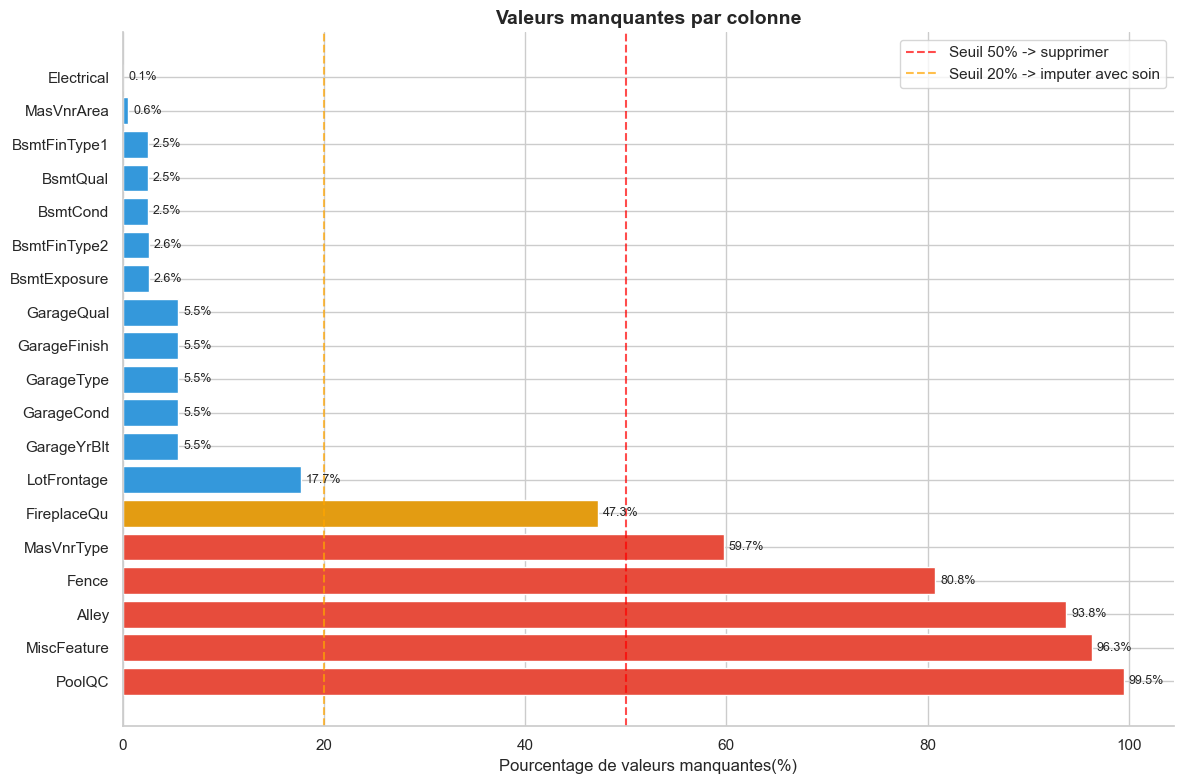

In [6]:
# Detection des valeurs nulls
missing = df.isnull().sum()
missing_pct = (missing/ len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Manquants" : missing,
    "Pourcentage %" : missing_pct}
).sort_values('Pourcentage %', ascending=False)
# Afficher seulement des colonnes avec manquants
missing_df = missing_df[missing_df['Manquants'] > 0]
print(f"Colonnes avec valeurs manquates : {len(missing_df)}")
print("=" * 45)
print(missing_df.to_string())
fig, ax =plt.subplots(figsize=(12,8))
couleurs = ["#E74C3C" if p > 50 else "#E39C12" if p> 20 else '#3498DB' for p in missing_df['Pourcentage %']]
bars = ax.barh(missing_df.index, missing_df["Pourcentage %"], color=couleurs
               ,edgecolor = 'white')
for bar, val in zip(bars, missing_df['Pourcentage %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(x=50, color='red', linestyle='--',
           alpha=0.7, label='Seuil 50% -> supprimer')
ax.axvline(x=20, color='orange',linestyle='--', alpha = 0.7,
           label='Seuil 20% -> imputer avec soin')
ax.set_title('Valeurs manquantes par colonne', fontsize=14, fontweight='bold')
ax.set_xlabel("Pourcentage de valeurs manquantes(%)")
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/01_Analyses_des_valeurs_manquantes.png',dpi=150, bbox_inches='tight')
plt.show()

#### Analyse de graphique "Valeur manquantes par colonne":

    -  50 % manquantes  -> **supprimer**  (4 colonnes):
        -   (PoolQC, MiscFeatures, Allet, Fence, MasVnrType)
    - 20 - 50 % -> IMPUTER AVEC SOIN (1 colonne)
        -  Fireplace (47%) -> signifie "pas de cheminée" ->  remplacer par 'None'
    - < 20 % manquants -> IMPUTER standard (14 clonnes)
        - LotFrontage, Garage*, Bsmt*, MasVnrArea, Electrical

In [7]:
# Nettoyge des données:
df_clean = df.copy()

# ── 1. Supprimer colonnes > 50% manquants ────────────────────
# Ces colonnes ont trop peu de données pour être utiles
cols_supprimer = ['PoolQC', 'MiscFeature', 'Alley', 
                  'Fence', 'MasVnrType']
df_clean = df_clean.drop(columns=cols_supprimer)

print(f"Colonnes supprimées : {cols_supprimer}")

# ── 2. FireplaceQu (47%) → 'None' = pas de cheminée ─────────
# NaN ne signifie pas "donnée manquante" mais "pas de cheminée"
# C'est une information en soi !
df_clean['FireplaceQu'] = df_clean['FireplaceQu'].fillna('None')

# ── 3. Colonnes Garage (5.5%) ─────────────────────────────────
# NaN = pas de garage → 'None' pour catégorielles, 0 pour numériques
cols_garage_cat = ['GarageType', 'GarageFinish', 
                   'GarageQual', 'GarageCond']
cols_garage_num = ['GarageYrBlt']

for col in cols_garage_cat:
    df_clean[col] = df_clean[col].fillna('None')
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)

# ── 4. Colonnes Basement (2.5%) ───────────────────────────────
# NaN = pas de sous-sol
cols_bsmt_cat = ['BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in cols_bsmt_cat:
    df_clean[col] = df_clean[col].fillna('None')

# ── 5. LotFrontage (17%) → médiane par quartier ───────────────
# Les maisons du même quartier ont souvent des facades similaires
# → imputation par groupe = plus intelligente que la médiane globale
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage']\
    .transform(lambda x: x.fillna(x.median()))

# ── 6. MasVnrArea (0.55%) → 0 ────────────────────────────────
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

# ── 7. Electrical (0.07%) → mode 'fill with the same repetative element'──────────────────────────────
df_clean['Electrical'] = df_clean['Electrical']\
    .fillna(df_clean['Electrical'].mode()[0])

# ── Vérification finale ───────────────────────────────────────
remaining = df_clean.isnull().sum().sum()
print(f"\nValeur manquantes avant le nettoyage: {missing.sum()}")
print(f"\nValeurs manquantes restantes : {remaining}")
print(f"\nShape après nettoyage        : {df_clean.shape}")

Colonnes supprimées : ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

Valeur manquantes avant le nettoyage: 7829

Valeurs manquantes restantes : 0

Shape après nettoyage        : (1460, 75)


In [8]:
df_fe = df_clean.copy()
# Age de la maison à la vente
df_fe['age_maison'] = df_fe['YrSold'] - df_fe['YearBuilt']
# Age de la maison depuis la dernière rénovation
df_fe['age_renovation'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
# Surface total habitable
# sommer toutes les surface en une seule variable puissante
df_fe['Surface_totale'] = (df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] +df_fe['2ndFlrSF'])
#Surface extérieure total
df_fe['Surface_exterieure'] = (df_fe['WoodDeckSF'] +
                               + df_fe['OpenPorchSF'] + 
                               df_fe['EnclosedPorch']+
                               +df_fe['3SsnPorch']+
                               df_fe['ScreenPorch'])
#Nombre total de salles de bain-----------
df_fe['total_bains'] = (df_fe['FullBath'] +
                         df_fe['HalfBath'] * 0.5 + 
                         df_fe['BsmtFullBath'] + 
                         df_fe['BsmtHalfBath'] * 0.5)
# Maison rénovée récemment
df_fe['renovee_recemment'] = (
    df_fe['YearRemodAdd'] == df_fe['YrSold']
).astype(int)
#Score qualité x surface: Interactionclé: Grande maison de Qualité vaut beaucoup plus
df_fe['qualite_x_surface'] = (df_fe['OverallQual'] * df_fe['Surface_totale'])
# Maison neuve à la vente
df_fe['maison_neuve'] = (df_fe['YrSold'] == df_fe['YearBuilt']).astype(int)
print("Nouvelles colonnes créées : ")
nouvelles = ['age_maison','age_renovation','Surface_totale','Surface_exterieure',
             'total_bains','renovee_recemment','qualite_x_surface','maison_neuve']
for col in nouvelles:
    print(f" {col:25s} -> "
          f"mean: {df_fe[col].mean():.1f} | "
          f"max: {df_fe[col].max():.1f}")

Nouvelles colonnes créées : 
 age_maison                -> mean: 36.5 | max: 136.0
 age_renovation            -> mean: 22.9 | max: 60.0
 Surface_totale            -> mean: 2567.0 | max: 11752.0
 Surface_exterieure        -> mean: 181.3 | max: 1027.0
 total_bains               -> mean: 2.2 | max: 6.0
 renovee_recemment         -> mean: 0.1 | max: 1.0
 qualite_x_surface         -> mean: 16416.0 | max: 117520.0
 maison_neuve              -> mean: 0.0 | max: 1.0


In [14]:
# Traintement des variable catégorielles
df_encoded = df_fe.copy()
cols_cat = df_encoded.select_dtypes(include=['object']).columns.tolist()
cols_num = df_encoded.select_dtypes(include=['int64','float64']).columns.tolist()
cols_num.remove('SalePrice')
print(f"Variable numériques : {len(cols_num)}")
print(f"Variables catégorielles: {len(cols_cat)}")
df_encoded = pd.get_dummies(df_encoded, columns=cols_cat,
                             drop_first=True, dtype=int)
print(f"\nShape avant encodage : {df_fe.shape}")
print(f"Shape après encodage : {df_encoded.shape}")
print(f"{df_encoded.shape[1] - df_fe.shape[1]} nouvelles colonnes créées par One-Hot Encoding")

Variable numériques : 44
Variables catégorielles: 38

Shape avant encodage : (1460, 83)
Shape après encodage : (1460, 252)
169 nouvelles colonnes créées par One-Hot Encoding


Features disponible : 251
Top 20 features les plus importantes: 
  1. qualite_x_surface              -> 4,002
  2. OverallQual                    -> 2,437
  3. Surface_totale                 -> 2,299
  4. GrLivArea                      -> 1,471
  5. GarageCars                     -> 1,014
  6. total_bains                    -> 968
  7. GarageArea                     -> 927
  8. TotalBsmtSF                    -> 880
  9. 1stFlrSF                       -> 846
 10. ExterQual_TA                   -> 775
 11. FullBath                       -> 668
 12. TotRmsAbvGrd                   -> 581
 13. age_maison                     -> 550
 14. YearBuilt                      -> 549
 15. KitchenQual_TA                 -> 538
 16. age_renovation                 -> 510
 17. YearRemodAdd                   -> 505
 18. Foundation_PConc               -> 480
 19. MasVnrArea                     -> 419
 20. FireplaceQu_None               -> 418

 Features retenues : 50
Shape final X: (1460, 50)


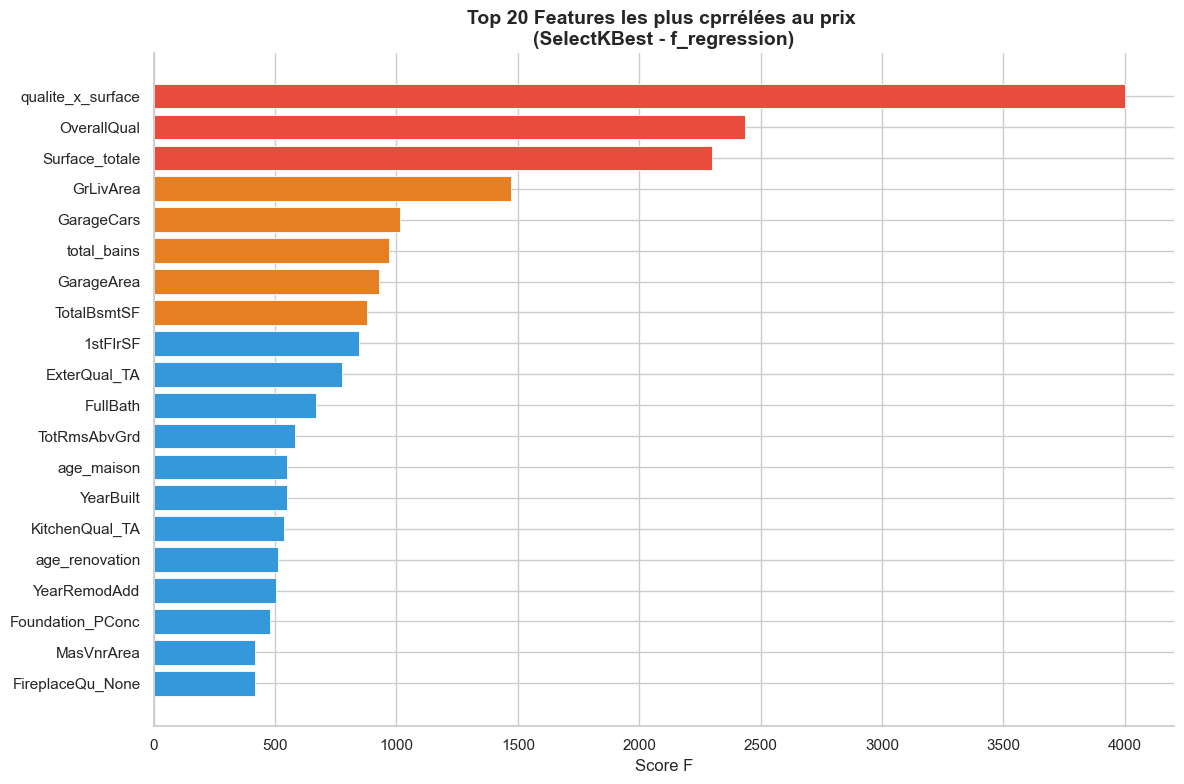

In [29]:
X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']
print(f"Features disponible : {X.shape[1]}")
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)
X_imp.head()
selector = SelectKBest(f_regression, k=50)
selector.fit(X_imp,y)
mask = selector.get_support()
features_top = X_imp.columns[mask].tolist()
scores_df = pd.DataFrame({'Feature' : X_imp.columns,
                          'Score' : selector.scores_}).sort_values('Score',ascending=False)
print("Top 20 features les plus importantes: ")
print("=" * 50)
for i, (_, row) in enumerate(scores_df.head(20).iterrows(),1):
    print(f" {i:2d}. {row['Feature']:30s} -> {row['Score']:,.0f}")
top20 = scores_df.head(20)
fig, ax = plt.subplots(figsize=(12,8))
couleurs = ['#E74C3C' if i < 3 else '#E67E22' if i<8 else '#3498DB' for i in range(20)]
bars = ax.barh(top20['Feature'][::-1],top20['Score'][::-1],color=couleurs[::-1],
               edgecolor='white',linewidth=0.6)
ax.set_title('Top 20 Features les plus cprrélées au prix \n''(SelectKBest - f_regression)', fontsize = 14, fontweight='bold')
ax.set_xlabel('Score F')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/02_top20_features.png',dpi=150, bbox_inches='tight')
X_selected = X_imp[features_top]
print(f"\n Features retenues : {X_selected.shape[1]}")
print(f"Shape final X: {X_selected.shape}")
plt.show()


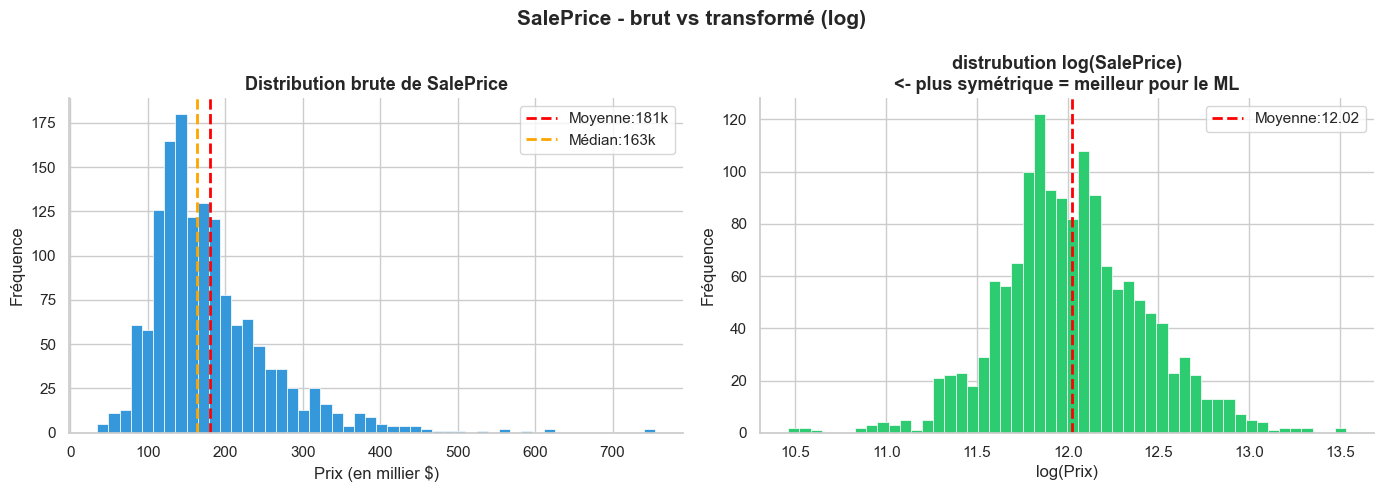

Skewness brut : 1.883 (1 > = très asymétrique)
skewness log : 0.121(proche de 0 = symétrique)


In [50]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(y/1000,bins=50,color='#3498DB',edgecolor='white', linewidth=0.5)
axes[0].axvline(y.mean()/1000, color='red', linestyle='--',linewidth=2, label=f"Moyenne:{y.mean()/1000:,.0f}k")
axes[0].axvline(y.median()/1000,color='orange',linestyle='--',linewidth=2, label=f"Médian:{y.median()/1000:,.0f}k")
axes[0].set_title('Distribution brute de SalePrice', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prix (en millier $)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# On utilise le log car les prix sont asymétriques 
# log rend la distrubution plus normale -> meilleure pour les modèles

y_log = np.log1p(y)
axes[1].hist(y_log, bins=50,color='#2ECC71',edgecolor='white', linewidth=0.5)
axes[1].axvline(y_log.mean(),color='red',linestyle='--', linewidth=2, label=f"Moyenne:{y_log.mean():.2f}")
axes[1].set_title('distrubution log(SalePrice)\n''<- plus symétrique = meilleur pour le ML', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Prix)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('SalePrice - brut vs transformé (log)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_distrubution_saleprice.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Skewness brut : {y.skew():.3f}" f" (1 > = très asymétrique)")
print(f"skewness log : {y_log.skew():.3f}" f"(proche de 0 = symétrique)")

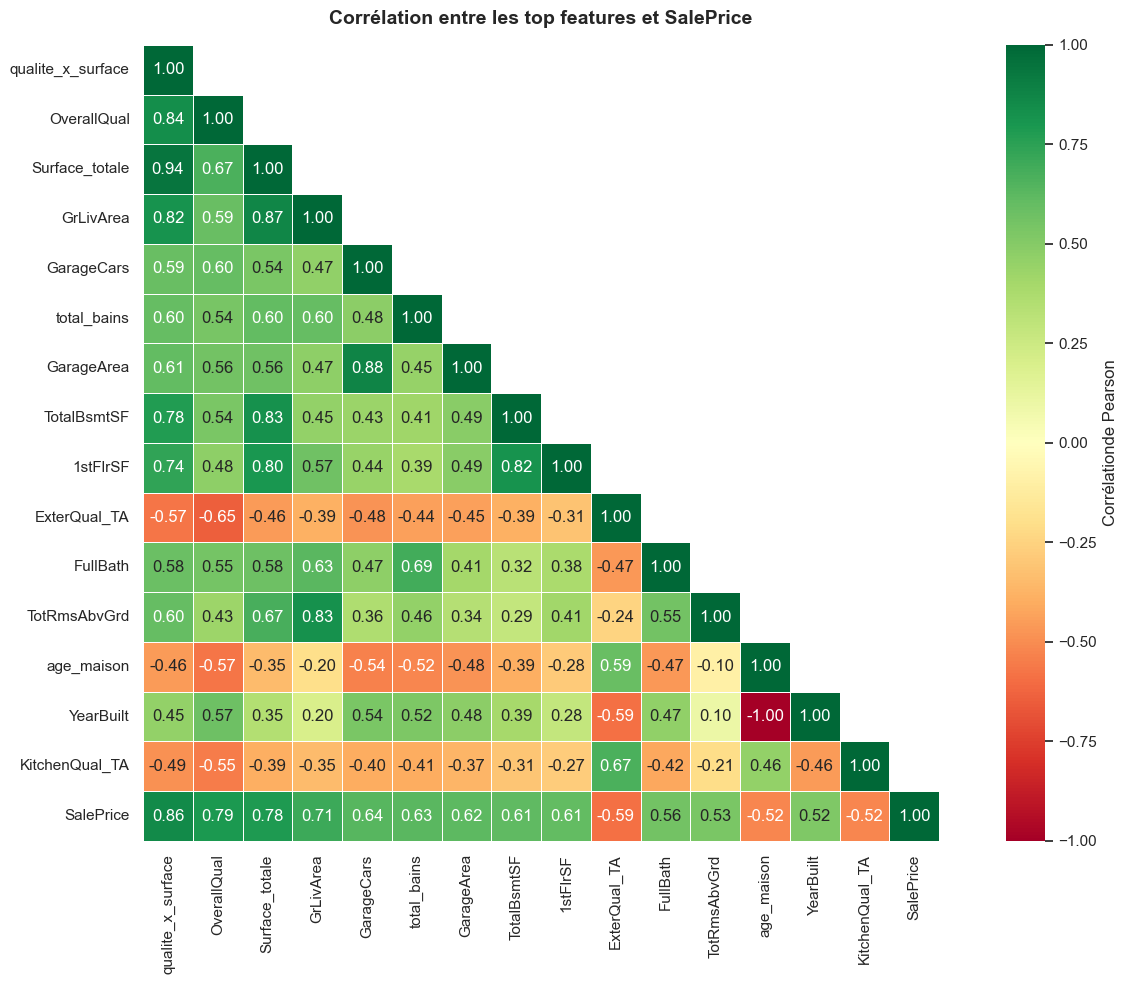

In [94]:
top15_num = scores_df[scores_df['Feature'].isin(
                df_encoded.select_dtypes(include=['int64','float64']).columns)].head(15)['Feature'].tolist()
cols_corr = [f for f in top15_num if f in df_encoded.columns]
corr_data = df_encoded[cols_corr + ['SalePrice']].corr()
mask = np.triu(np.ones_like(corr_data,dtype=bool),k=1)
fig,ax = plt.subplots(figsize=(14,10))
sns.heatmap(corr_data,annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0,vmin=-1, vmax=1, linewidths=0.5, linecolor='white', square=True, ax=ax,mask=mask,
            cbar_kws={'label' : 'Corrélationde Pearson'})
ax.set_title('Corrélation entre les top features et SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.grid(False)
plt.savefig('../outputs/04_heatmap_correlation.png',dpi=150,bbox_inches='tight')
plt.show()

In [95]:
# Split train / test
y_log = np.log1p(y)
X_train, X_test, y_train, y_test = train_test_split(X_selected,y_log,test_size=0.2,random_state=42)
print(f"Train : {X_train.shape[0]} maisons")
print(f"Test : {X_test.shape[0]} maisons")
print(f"Features : {X_train.shape[1]}")

Train : 1168 maisons
Test : 292 maisons
Features : 50


In [99]:
#Apprentissage du model on utlise différents modeles pour comparaison 
# du model le plus efficaces
modeles = {
    'Régression linéaire' : LinearRegression(),
    'Ridge' : Ridge(alpha=10),
    'Lasso' : Lasso(alpha=0.001),
    'Random Forest' : RandomForestRegressor(
        n_estimators=200,max_depth=15,random_state=42
    ),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,
                                                    max_depth=4,random_state=42)
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultas = {}
print("=" * 60)
print("Résultats - AMES HOUSING ML")
print("=" * 65)
for nom, modele in modeles.items():
    pipeline= Pipeline([
        ('scaler',StandardScaler()),('model', modele)
    ])
    #Validation cross
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
    # Entrainement final sur tout le train
    pipeline.fit(X_train,y_train)
    y_pred_log = pipeline.predict(X_test)
    # Reconversion du log en prix réels 
    y_pred_reel = np.expm1(y_pred_log)
    y_test_reel = np.expm1(y_test)
    mae = mean_absolute_error(y_test_reel,y_pred_reel)
    rmse = np.sqrt(mean_squared_error(y_test_reel,y_pred_reel))
    r2 = r2_score(y_test_reel,y_pred_reel)
    resultas[nom] = {
            'MAE': mae,
            'RMSE' : rmse,
            'R2' : r2,
            'CV_mean' : cv_scores.mean(),
            'CV_std' : cv_scores.std(),
            'pipeline' : pipeline,
            'preds' : y_pred_reel
    }
    print(f"\n {nom}")
    print(f" R2 test : {r2:.4f}")
    print(f"R2 CV : {cv_scores.mean():.4f}" f" +_ {cv_scores.std():.4f}")
    print(f" MAE :  {mae:,.0f}$")
    print(f" RMSE : {rmse:,.0f} $")
    

Résultats - AMES HOUSING ML

 Régression linéaire
 R2 test : 0.8580
R2 CV : 0.8395 +_ 0.0508
 MAE :  18,979$
 RMSE : 32,997 $

 Ridge
 R2 test : 0.8736
R2 CV : 0.8348 +_ 0.0631
 MAE :  18,603$
 RMSE : 31,141 $

 Lasso
 R2 test : 0.8712
R2 CV : 0.8334 +_ 0.0680
 MAE :  18,619$
 RMSE : 31,431 $

 Random Forest
 R2 test : 0.8888
R2 CV : 0.8578 +_ 0.0178
 MAE :  17,643$
 RMSE : 29,207 $

 Gradient Boosting
 R2 test : 0.9020
R2 CV : 0.8730 +_ 0.0212
 MAE :  17,579$
 RMSE : 27,422 $


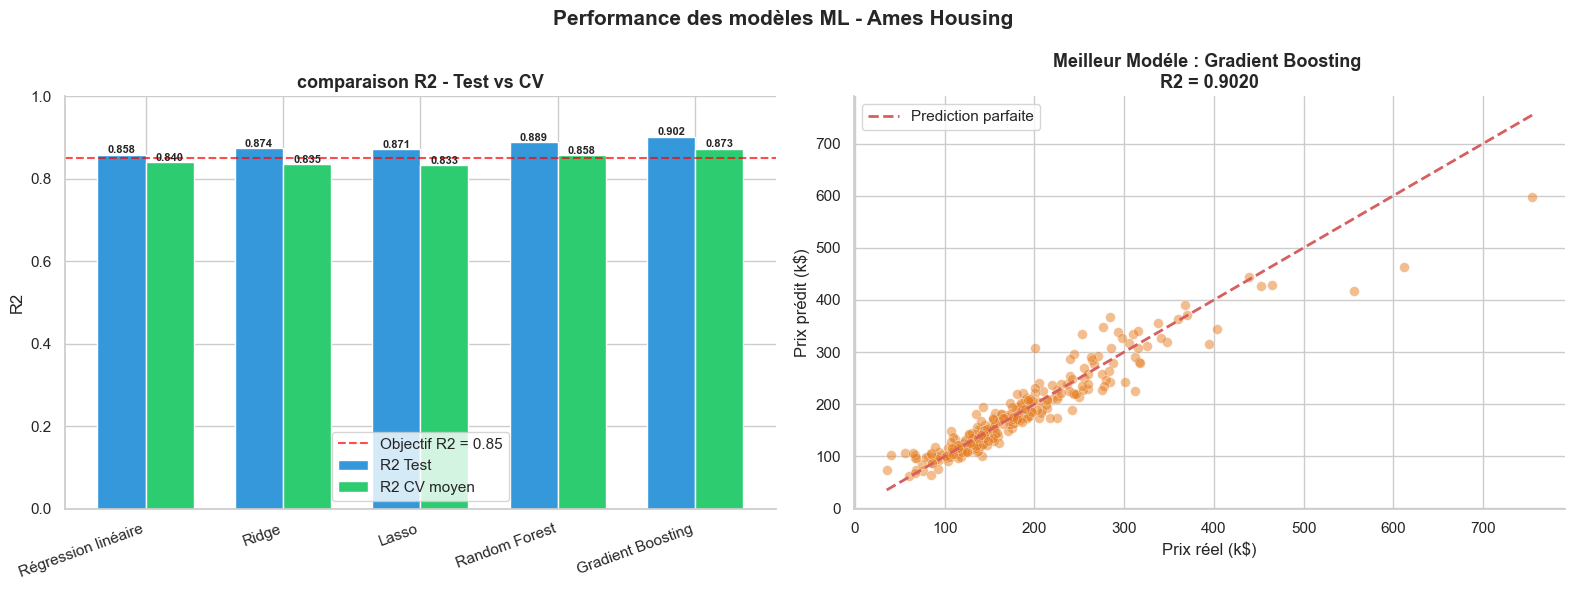


 Meilleur modèle : Gradient Boosting
R2 : 0.9020
Mae: 17,579$
RMSE: 27,422$


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(16,6))
noms = list(resultas.keys())
r2_test = [resultas[n]['R2'] for n in noms]
r2_cv = [resultas[n]['CV_mean'] for n in noms]
x = np.arange(len(noms))
width = 0.35
bars1 = axes[0].bar(x - width/2, r2_test, width,label='R2 Test', color='#3498DB', edgecolor='white')
bars2 = axes[0].bar(x+width/2,r2_cv,width,label='R2 CV moyen', color='#2ECC71', edgecolor='White')
for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(noms, rotation=20, ha='right')
axes[0].set_ylabel('R2')
axes[0].set_ylim(0,1)
axes[0].axhline(y=0.85, color='red',linestyle='--',alpha=0.7,label='Objectif R2 = 0.85')
axes[0].set_title('comparaison R2 - Test vs CV', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)
# -- Meilleur modèle : prédit vs réel ------
meilleur = max(resultas, key=lambda x: resultas[x]['R2'])
y_pred_best = resultas[meilleur]['preds']
axes[1].scatter(y_test_reel / 1000, y_pred_best /1000, alpha=0.5,
                color='#E67E22', edgecolors='white',linewidth=0.4,s=50)
min_val = min(y_test_reel.min(),y_pred_best.min())/1000
max_val = max(y_test_reel.max(),y_pred_best.max())/1000
axes[1].plot([min_val, max_val], [min_val,max_val],'r--',linewidth=2, label='Prediction parfaite')
axes[1].set_title(f'Meilleur Modéle : {meilleur} \n'
                  f'R2 = {resultas[meilleur]["R2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prix réel (k$)')
axes[1].set_ylabel('Prix prédit (k$)')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Performance des modèles ML - Ames Housing', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_comparaison_modeles.png',dpi=150, bbox_inches='tight')
plt.show()
meilleur = max(resultas,key=lambda x:resultas[x]['R2'])
print(f"\n Meilleur modèle : {meilleur}")
print(f"R2 : {resultas[meilleur]['R2']:.4f}")
print(f"Mae: {resultas[meilleur]['MAE']:,.0f}$")
print(f"RMSE: {resultas[meilleur]['RMSE']:,.0f}$")

En moyenne le modèle se trompe de 17,579$
sur un prix moyen de ~180,000$

Erreur relative = 17,579 / 180,000 = 9.8%

Pour une maison à 200,000$ :
→ le modèle prédit entre 182,000$ et 218,000$

C'est très acceptable pour un modèle
sans données GPS ou de voisinage précis 

In [124]:
# Prédiction sur une nouvelle maison
nouvelle = pd.DataFrame([X_selected.median().values], columns=X_selected.columns)
nouvelle['OverallQual'] = 8
nouvelle['Surface_totale'] = 2500
nouvelle['GarageCars'] = 2
nouvelle['age_maison'] = 10
nouvelle['total_bains'] = 3
nouvelle['qualite_x_surface'] = 8 * 2500

print("Maison à estimer:")
print(f"Qualité générale: 8/10")
print(f"Surface total : 2500 sq ft")
print(f"Garage : 2 voitures")
print(f"Age : 10 ans")
print(f"Salles de bain : 3")
print("\n" + "=" * 50)
print("Estimation par modèle")
print("=" * 50)
predictions = {}
for nom, res in resultas.items():
    prix_log = res['pipeline'].predict(nouvelle)[0]
    prix_reel = np.expm1(prix_log)
    predictions[nom] = prix_reel
    print(f" {nom:25s} -> {prix_reel:,.0f}$")
print('=' * 50)
prix_moyen = np.mean(list(predictions.values()))
print(f"{'prix moyen estimé' :25s} -> {prix_moyen:,.0f}")

Maison à estimer:
Qualité générale: 8/10
Surface total : 2500 sq ft
Garage : 2 voitures
Age : 10 ans
Salles de bain : 3

Estimation par modèle
 Régression linéaire       -> 190,650$
 Ridge                     -> 193,705$
 Lasso                     -> 203,091$
 Random Forest             -> 193,943$
 Gradient Boosting         -> 199,162$
prix moyen estimé         -> 196,110
